# Obligatorio 1 — Sistemas Multiagente (2026)
Ramiro Sanes - Joaquín Guerra — Universidad ORT Uruguay

---

Realizamos la **experimentación** sobre cuatro algoritmos de aprendizaje multiagente, poniéndolos a prueba en diversos entornos clásicos de teoría de juegos, tal como vimos a lo largo del semestre en las clases teóricas.

**Algoritmos que implementamos:**

| Algoritmo | Tipo | Referencia |
|-----------|------|------------|
| Fictitious Play (FP) | Basado en creencias | Brown, 1951 |
| Regret Matching (RM) | Minimización de arrepentimiento | Hart & Mas-Colell, 2000 |
| Independent Q-Learning (IQL) | RL independiente | Tan, 1993 |
| Joint-Action Learning (JAL-AM) | RL con modelado de oponente | Claus & Boutilier, 1998 |
| Random Agent | Baseline (para comprobar si realmente aprenden) | — |

**Ambientes de validación:** Matching Pennies, Rock-Paper-Scissors, Blotto (5 soldados, 3 frentes), Battle of the Sexes, Chicken y un entorno de grilla (Foraging).

---
## 1. Setup e Imports

Cargamos todos los agentes, juegos y funciones auxiliares desde `utils.py`.

In [4]:
import os, sys

# Use the current notebook working directory instead of a hardcoded path.
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils import *
from games.rps import RPS
from games.mp import MP
from games.blotto import Blotto
from games.bos import BoS
from games.chicken import Chicken
from games.blotto_original import Blotto_Original

setup_plot_style()

AGENTS = ['FP', 'RM', 'IQL', 'JAL', 'Random']
N = 10000

print('✅ Entorno cargado — 5 agentes, 5+ juegos disponibles')

✅ Entorno cargado — 5 agentes, 5+ juegos disponibles


---
## 2. Rock-Paper-Scissors (RPS)

**Tipo:** Juego de suma cero simétrico · 3 acciones · **Nash:** π* = (⅓, ⅓, ⅓) · **V* = 0**

| | Rock | Paper | Scissors |
|---|:---:|:---:|:---:|
| **Rock** | 0, 0 | -1, 1 | 1, -1 |
| **Paper** | 1, -1 | 0, 0 | -1, 1 |
| **Scissors** | -1, 1 | 1, -1 | 0, 0 |


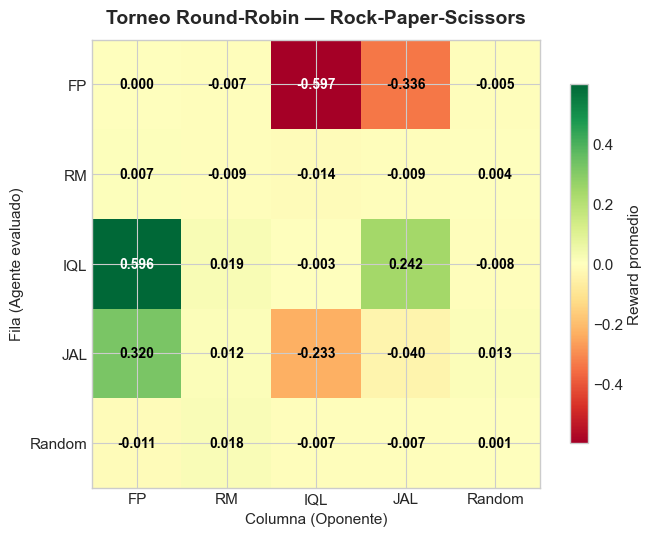

  Ranking en RPS:
    1.    Independent Q-Learning:   0.1693  ██████████
    2.      JAL – Agent Modeling:   0.0145  ███████
    3.              Random Agent:  -0.0014  ███████
    4.           Regret Matching:  -0.0042  ███████
    5.           Fictitious Play:  -0.1891  ████



In [5]:
rps_m = run_tournament(RPS, AGENTS, n_episodes=N)
plot_tournament_heatmap(rps_m, AGENTS, 'Rock-Paper-Scissors')
print_ranking(rps_m, AGENTS, 'RPS')

### 2.1 Convergencia de Políticas en RPS
Veamos cómo evoluciona la distribución de probabilidad sobre las acciones a lo largo del entrenamiento para distintos enfrentamientos.

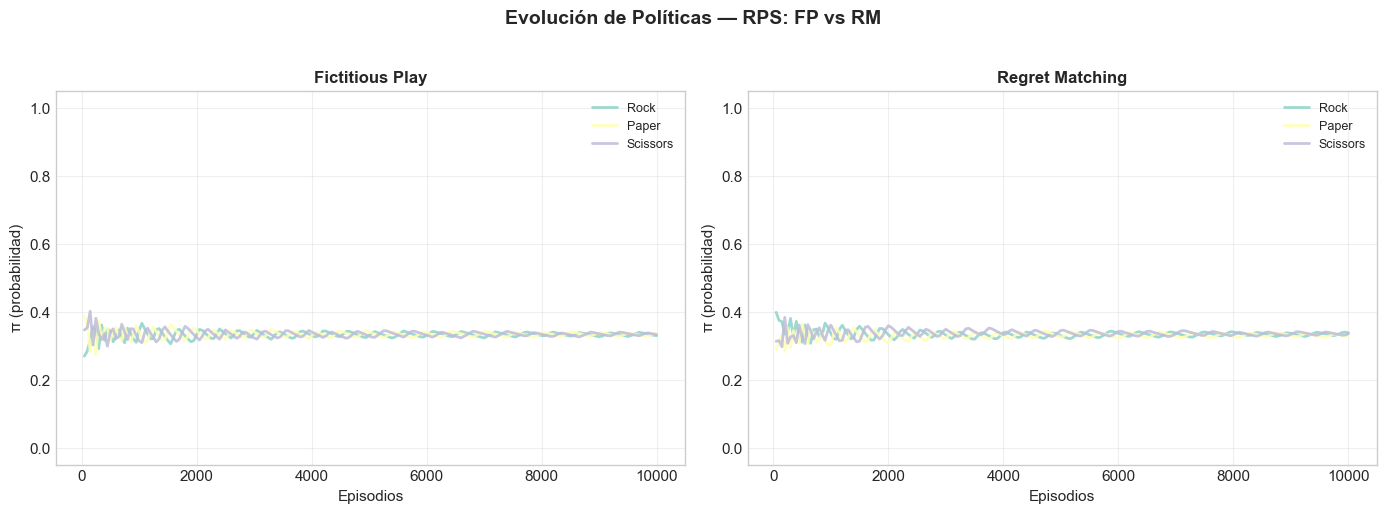

Políticas finales aprendidas:
            Fictitious Play:  [0.3295, 0.3379, 0.3325]
            Regret Matching:  [0.3381, 0.3269, 0.3350]



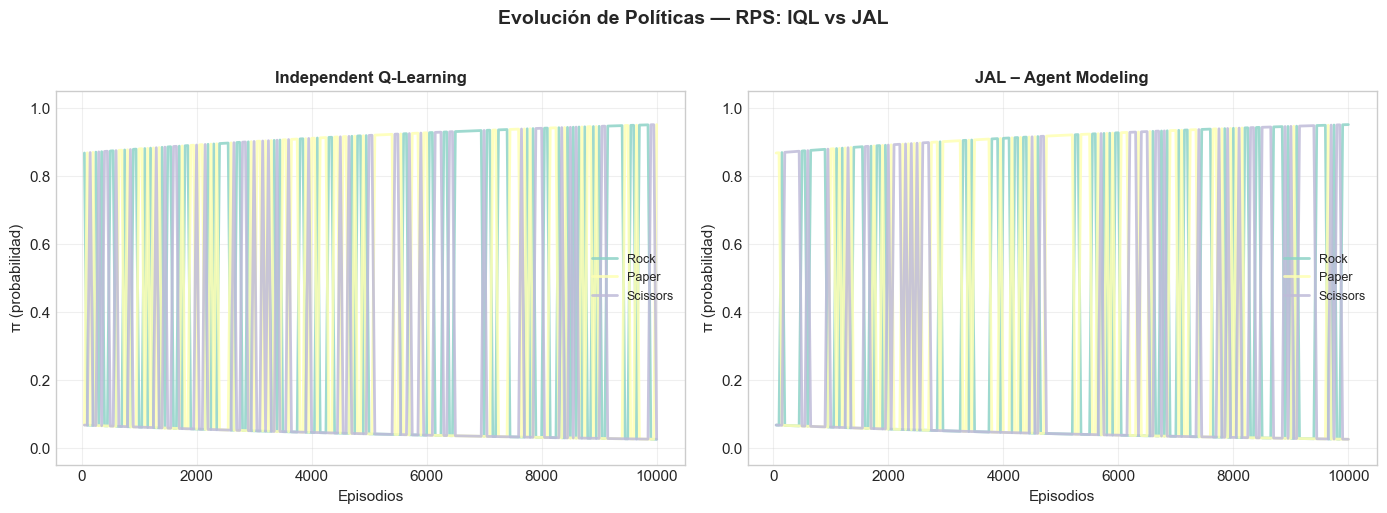

Políticas finales aprendidas:
     Independent Q-Learning:  [0.0245, 0.9509, 0.0245]
       JAL – Agent Modeling:  [0.9509, 0.0245, 0.0245]



In [6]:
L = ['Rock', 'Paper', 'Scissors']

r = run_experiment(RPS, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'RPS', action_labels=L)
print_final_policies(r)

r = run_experiment(RPS, ['IQL', 'JAL'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'RPS', action_labels=L)
print_final_policies(r)

### Análisis de Convergencia en Rock-Paper-Scissors
FP y RM en RPS funcionan como esperábamos: ambos convergen a jugar cada acción un tercio del tiempo, que es el equilibrio de Nash del juego. Al principio oscilan un poco mientras se van "conociendo", pero se estabilizan rápido. La diferencia entre los dos es el mecanismo — FP mira qué juega el oponente y responde a eso, RM mira cuánto se arrepiente de sus propias jugadas — pero el resultado final es el mismo.

IQL y JAL en RPS en cambio no convergen al equilibrio. Lo que pasa es que se terminan explotando mutuamente: IQL aprende a jugar casi siempre Paper, JAL aprende a jugar casi siempre Rock, y se quedan ahí. El problema de fondo es que estos algoritmos asumen que el entorno es estable mientras aprenden, pero en realidad los dos están cambiando al mismo tiempo, lo que rompe esa suposición. Básicamente no son los algoritmos indicados para este tipo de juego.

---
## 3. Matching Pennies (MP)

**Tipo:** Juego de suma cero simétrico · 2 acciones · **Nash:** π* = (½, ½) · **V* = 0**

| | Heads | Tails |
|---|:---:|:---:|
| **Heads** | 1, -1 | -1, 1 |
| **Tails** | -1, 1 | 1, -1 |


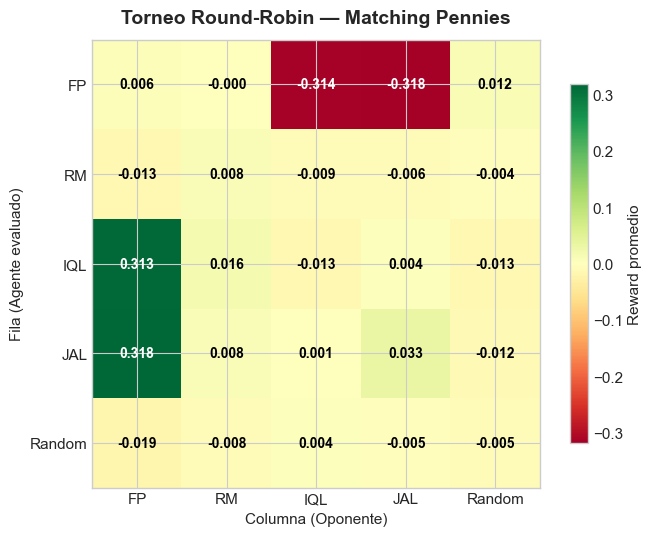

  Ranking en Matching Pennies:
    1.      JAL – Agent Modeling:   0.0694  ████████
    2.    Independent Q-Learning:   0.0614  ████████
    3.           Regret Matching:  -0.0050  ███████
    4.              Random Agent:  -0.0065  ███████
    5.           Fictitious Play:  -0.1229  █████



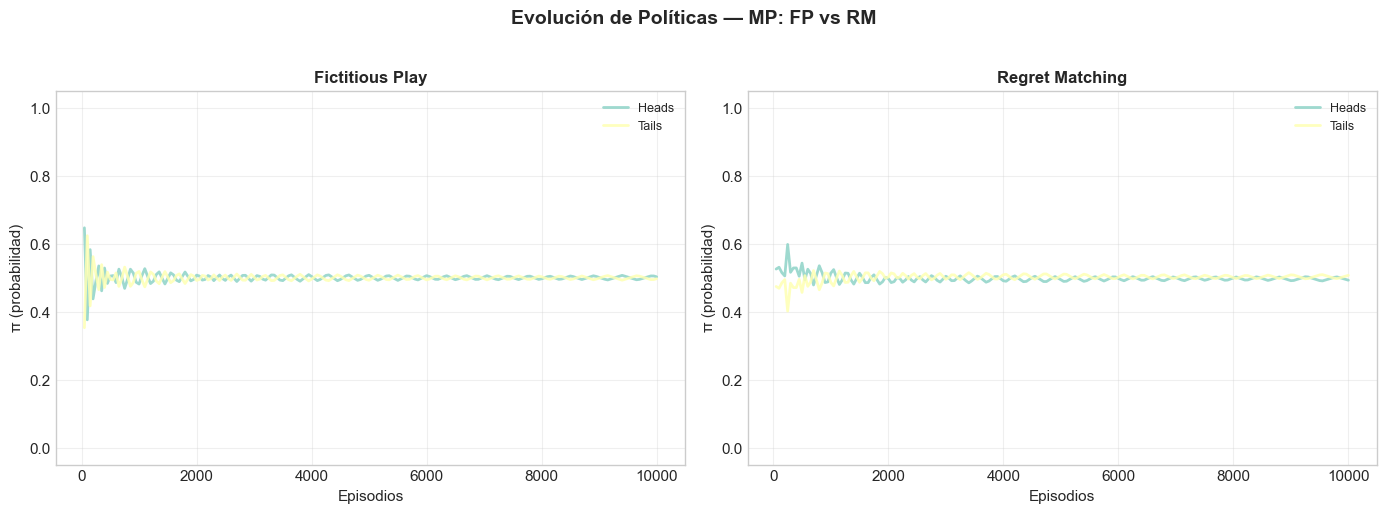

Políticas finales aprendidas:
            Fictitious Play:  [0.5027, 0.4973]
            Regret Matching:  [0.4928, 0.5072]



In [7]:
mp_m = run_tournament(MP, AGENTS, n_episodes=N)
plot_tournament_heatmap(mp_m, AGENTS, 'Matching Pennies')
print_ranking(mp_m, AGENTS, 'Matching Pennies')

r = run_experiment(MP, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'MP', action_labels=['Heads', 'Tails'])
print_final_policies(r)

### Análisis de Convergencia en Matching Pennies
MP es otro juego de suma cero donde el equilibrio de Nash es jugar cada acción con 50% de probabilidad. FP y RM convergen a ese equilibrio de forma similar a lo que vimos en RPS.

---
## 4. Blotto

**Tipo:** Juego de suma cero de asignación estratégica de recursos · Múltiples acciones combinatoriales.

Cada jugador distribuye S=3 soldados en N=2 frentes. Gana el frente quien asigna más soldados. El jugador que gane más frentes recibe +1, pierde -1, empata 0.


  Ranking en Blotto:
    1.           Regret Matching:   0.0960  ████████
    2.           Fictitious Play:   0.0748  ████████
    3.    Independent Q-Learning:   0.0064  ███████
    4.      JAL – Agent Modeling:  -0.0016  ███████
    5.              Random Agent:  -0.1156  █████



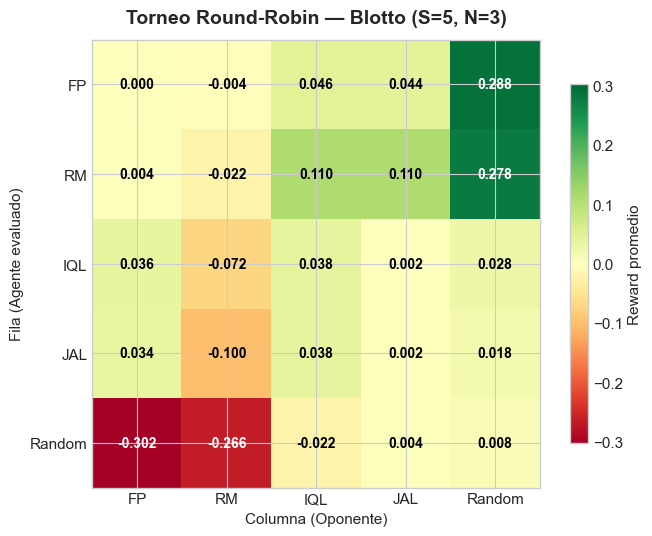

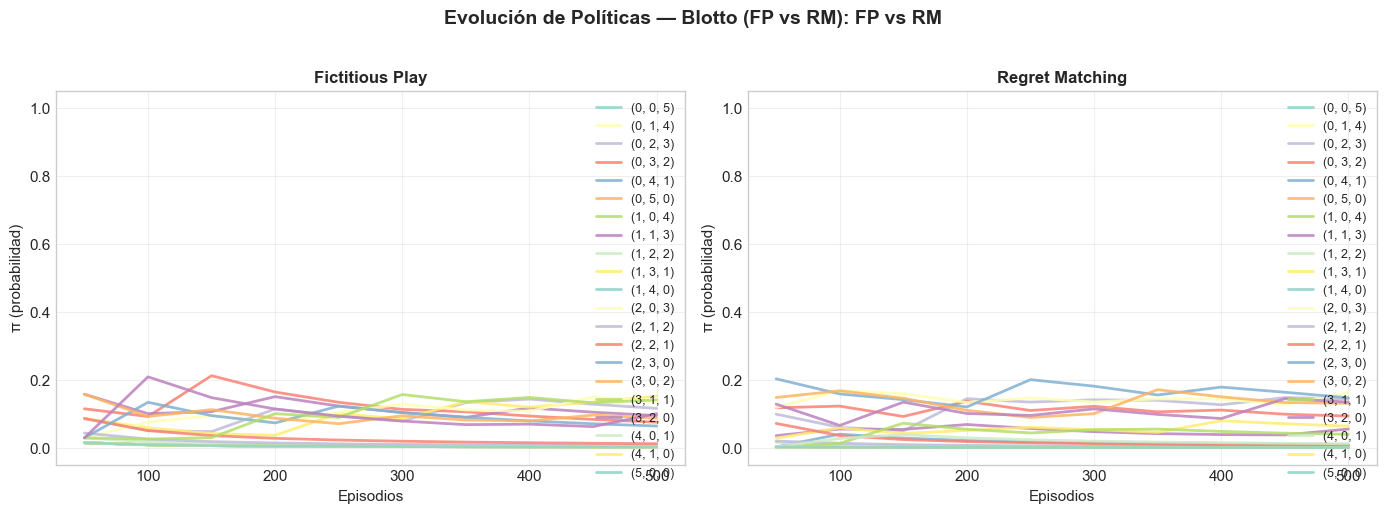

In [8]:
import importlib
import agents.fictitiousplay
import agents.regretmatching
importlib.reload(agents.fictitiousplay)
importlib.reload(agents.regretmatching)
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching

blotto_m = run_tournament(Blotto_Original, AGENTS, n_episodes=500, S=5, N=3)

print_ranking(blotto_m, AGENTS, "Blotto")
plot_tournament_heatmap(blotto_m, AGENTS, "Blotto (S=5, N=3)")

blotto_res = run_experiment(Blotto, ['FP', 'RM'], n_episodes=500, track_interval=50, S=5, N=3)

# Generar labels de las acciones para la gráfica (S=5, N=3)
dummy_game = Blotto(S=5, N=3)
blotto_labels = [str(tuple(m)) for m in dummy_game._moves]

plot_policy_evolution(blotto_res, "Blotto (FP vs RM)", action_labels=blotto_labels)

### Análisis de Convergencia en Battle of the Sexes
Blotto con 5 soldados y 3 frentes tiene 21 acciones posibles, lo que lo hace bastante más complejo que RPS o MP. Los resultados del torneo son claros: RM y FP dominan, con promedios positivos contra todos los oponentes, mientras que Random pierde fuerte contra ambos (-0.302 y -0.266).
Lo interesante de las gráficas de evolución es que FP y RM no convergen a una sola táctica sino que aprenden una distribución sobre un subconjunto de tácticas efectivas, dejando las acciones más débiles cerca de cero. Tiene sentido — en Blotto no hay una estrategia dominante pura, la mejor respuesta siempre depende de lo que haga el oponente.
IQL y JAL quedan en el medio: le ganan a Random pero no logran competir con FP y RM. En un juego con 21 acciones el espacio es demasiado grande para que el Q-learning converja bien en 10000 episodios, especialmente sin un diseño de estados adecuado.

---
## 5. Battle of the Sexes (BoS)

**Tipo:** Juego de coordinación (suma NO cero) · 2 acciones.

| | Opera | Fútbol |
|---|:---:|:---:|
| **Opera** | 2, 1 | 0, 0 |
| **Fútbol** | 0, 0 | 1, 2 |

Tiene **dos equilibrios puros** (Opera, Opera) y (Fútbol, Fútbol), y un **equilibrio mixto** donde cada jugador mezcla de forma asimétrica.


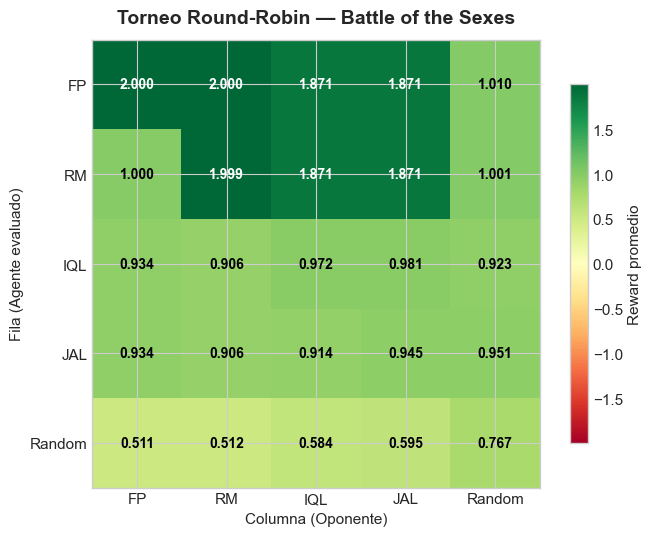

  Ranking en BoS:
    1.           Fictitious Play:   1.7506  █████████████████████████████████
    2.           Regret Matching:   1.5484  ██████████████████████████████
    3.    Independent Q-Learning:   0.9431  █████████████████████
    4.      JAL – Agent Modeling:   0.9299  █████████████████████
    5.              Random Agent:   0.5938  ████████████████



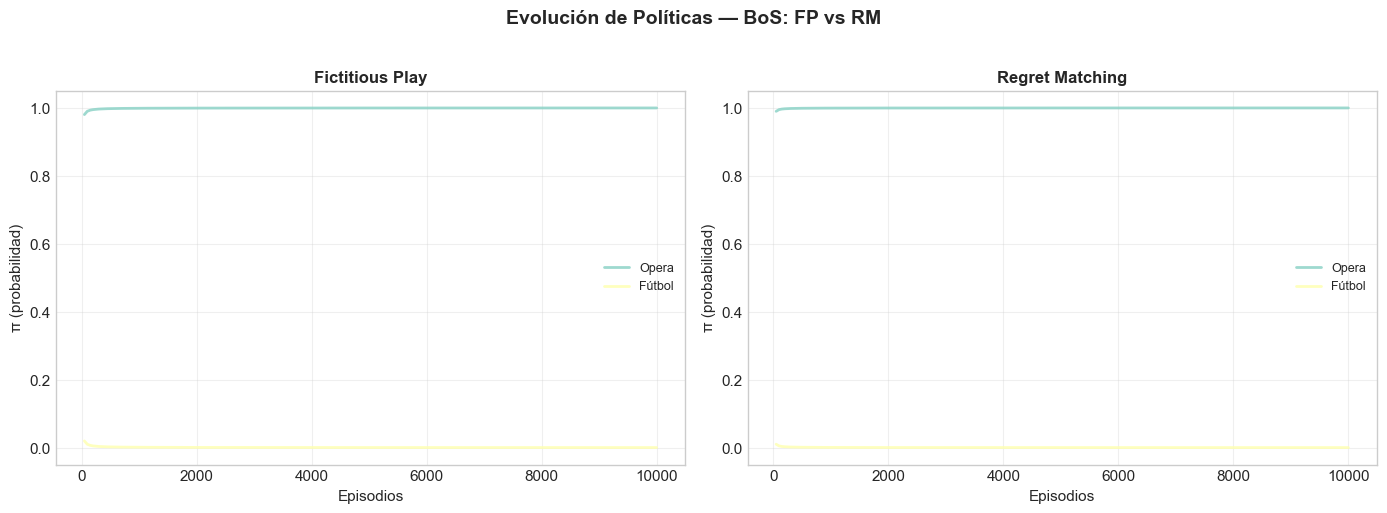

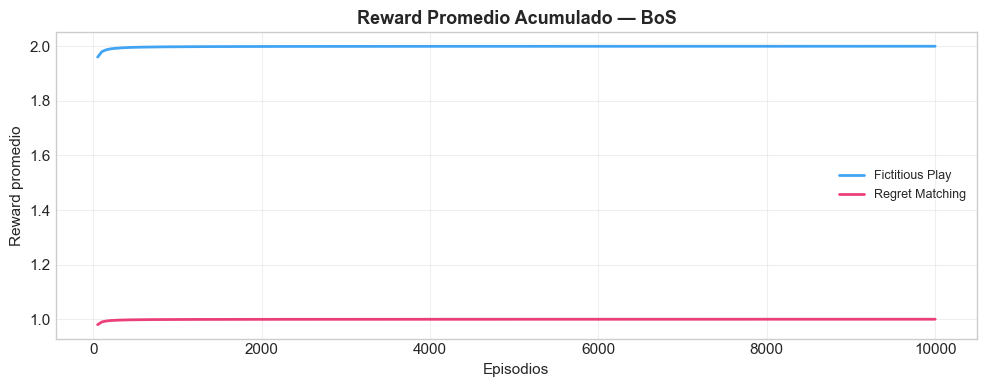

Políticas finales aprendidas:
            Fictitious Play:  [0.9999, 0.0001]
            Regret Matching:  [1.0000, 0.0001]



In [9]:
bos_m = run_tournament(BoS, AGENTS, n_episodes=N)
plot_tournament_heatmap(bos_m, AGENTS, 'Battle of the Sexes')
print_ranking(bos_m, AGENTS, 'BoS')

r = run_experiment(BoS, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'BoS', action_labels=['Opera', 'Fútbol'])
plot_reward_evolution(r, 'BoS')
print_final_policies(r)

### Análisis de Convergencia en Battle of the Sexes
BoS es nuestro primer juego de coordinación y los resultados claros. Tanto FP como RM convergen casi instantáneamente a un equilibrio puro. En este caso ambos eligen Opera desde el primer episodio y no se mueven de ahí.
El heatmap muestra algo interesante: FP vs RM da 2.000 y RM vs FP da 1.000. Esto no significa que FP sea mejor algoritmo — simplemente refleja que convergieron al equilibrio de Opera, donde el jugador 1 gana 2 y el jugador 2 gana 1. Si hubieran convergido a Fútbol sería al revés. El equilibrio al que llegan depende de la inicialización, no del algoritmo en sí.

IQL y JAL también coordinan pero con rewards menores (~0.93), lo que sugiere que no siempre logran caer en un equilibrio puro y mezclan algo más.

Random es el que peor coordina, como era de esperar.

---
## 6. Chicken (Halcón-Paloma / L-S)

**Tipo:** Juego de anti-coordinación (suma NO cero) · 2 acciones (S, L).

| | S | L |
|---|:---:|:---:|
| **S** | 0, 0 | 7, 2 |
| **L** | 2, 7 | 6, 6 |

Es una variante del dilema del prisionero o Chicken con matriz ajustada. (L, L) da una recompensa moderada (6, 6). Sin embargo, si uno juega S y el otro L, el que juega S obtiene 7 y el que juega L obtiene 2. Si ambos juegan S, obtienen 0.

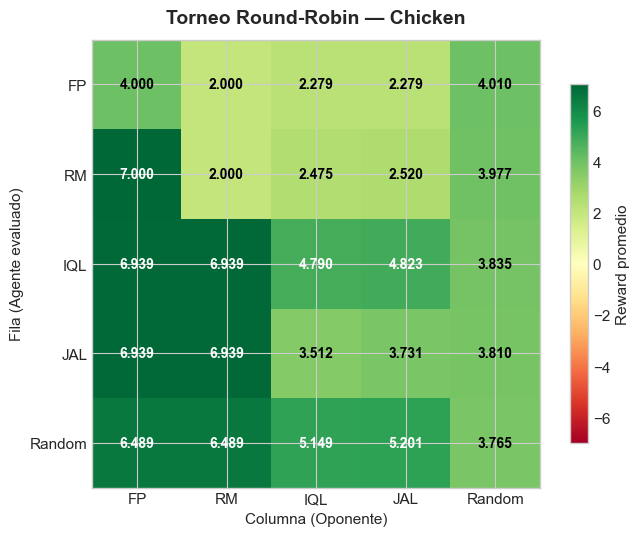

  Ranking en Chicken:
    1.    Independent Q-Learning:   5.4651  █████████████████████████████████████████████████████████████████████████████████████████
    2.              Random Agent:   5.4184  ████████████████████████████████████████████████████████████████████████████████████████
    3.      JAL – Agent Modeling:   4.9861  ██████████████████████████████████████████████████████████████████████████████████
    4.           Regret Matching:   3.5943  █████████████████████████████████████████████████████████████
    5.           Fictitious Play:   2.9136  ███████████████████████████████████████████████████



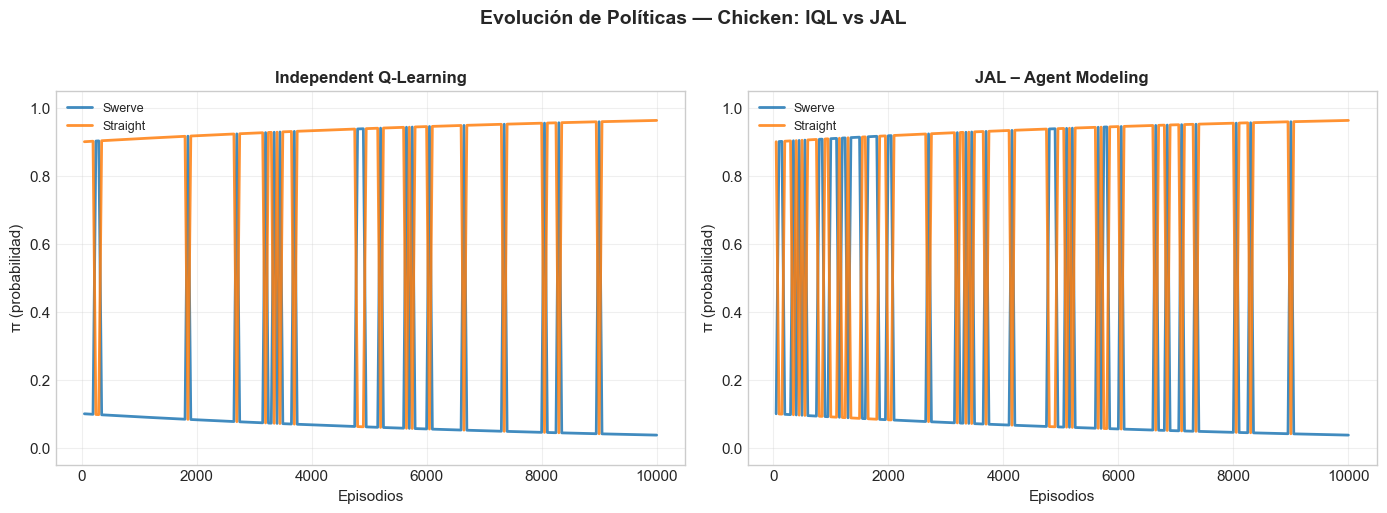

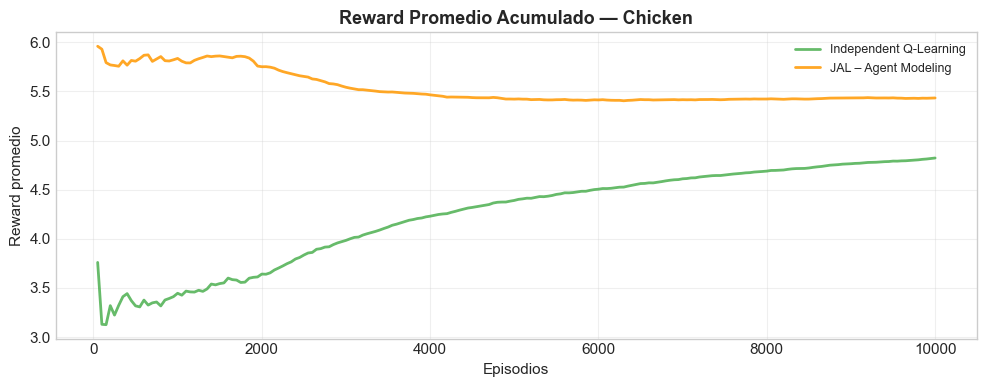

Políticas finales aprendidas:
     Independent Q-Learning:  [0.0368, 0.9632]
       JAL – Agent Modeling:  [0.0368, 0.9632]



In [8]:
ch_m = run_tournament(Chicken, AGENTS, n_episodes=N)
plot_tournament_heatmap(ch_m, AGENTS, 'Chicken')
print_ranking(ch_m, AGENTS, 'Chicken')

r = run_experiment(Chicken, ['IQL', 'JAL'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'Chicken', action_labels=['Swerve', 'Straight'])
plot_reward_evolution(r, 'Chicken')
print_final_policies(r)

### Análisis de Convergencia en Chicken
En Chicken IQL y JAL dominaron el torneo con rewards promedio de 5.47 y 4.99, mientras que FP y RM quedan últimos con 2.91 y 3.59.

La clave está en cómo cada algoritmo reacciona al oponente. Cuando IQL o JAL enfrentan a FP o RM, convergen rápidamente a jugar Swerve (S), lo que fuerza a FP y RM a quedarse jugando Straight (L) — el peor lado del equilibrio asimétrico, con reward 2. IQL y JAL se llevan 7. FP cae en esta trampa porque modela al oponente, ve que juega S, y responde con L esperando 6 o más, pero termina siendo el explotado.

Cuando IQL y JAL juegan entre sí, la dinámica cambiaa; ambos convergen a Straight (L) obteniendo (L,L) = 6,6, el mejor resultado conjunto posible. El gráfico de evolución de políticas muestra que este proceso no es inmediato: ambos ciclan entre S y L durante miles de episodios antes de estabilizarse.

Random supera a FP y RM en el ranking porque al mezclar acciones cae en (L,L) = 6,6 con cierta frecuencia, mientras FP y RM quedan bloqueados en Straight respondiendo a oponentes que juegan Swerve.

---
## 7. Foraging (Level-Based Foraging)

**Tipo:** Juego estocástico cooperativo/competitivo en gridworld · Múltiples estados · Acciones: NONE, UP, DOWN, LEFT, RIGHT, LOAD.

En este ambiente, 2 agentes se mueven en una grilla 5×5 buscando comida. Para recoger la comida necesitan estar en la celda correcta y ejecutar LOAD. La recompensa se otorga al recolectar exitosamente.

> A diferencia de los juegos matriciales anteriores (1 estado), Foraging tiene **múltiples estados** y **episodios con horizonte finito**. Solo IQL y JAL-AM están diseñados para esto, ya que mantienen tablas Q indexadas por estado.

In [12]:
import importlib
import agents.jal
importlib.reload(agents.jal)
from agents.jal import JAL

import lbforaging
from games.foraging import Foraging

def run_foraging_experiment(config, agent_name, n_episodes=200, seed=42):
    """Entrena agentes IQL o JAL en el ambiente Foraging y retorna rewards totales por episodio."""
    episode_rewards = []
    
    game = Foraging(config=config, seed=seed)
    
    agents_dict = {}
    for ag in game.agents:
        if agent_name == 'IQL':
            agents_dict[ag] = IQL(game=game, agent=ag, alpha=0.1, epsilon=0.3,
                            min_epsilon=0.05, epsilon_decay=0.999, gamma=0.95, seed=seed)
        elif agent_name == 'JAL':
            agents_dict[ag] = JAL(game=game, agent=ag, alpha=0.1, epsilon=0.3,
                            min_epsilon=0.05, epsilon_decay=0.999, gamma=0.95, seed=seed)
        else:
            agents_dict[ag] = RandomAgent(game=game, agent=ag)
    
    for ep in tqdm(range(n_episodes), desc=f'{agent_name} - {config}', leave=False):
        game.reset()
        for ag in game.agents:
            if hasattr(agents_dict[ag], 'reset'):
                agents_dict[ag].reset()
        
        ep_reward = {ag: 0.0 for ag in game.agents}
        
        while not game.done():
            actions = {ag: agents_dict[ag].action() for ag in game.agents}
            game.step(actions)
            for ag in game.agents:
                ep_reward[ag] += game.reward(ag)
                # Pass actions to JAL so it knows what opponents played
                if hasattr(agents_dict[ag], 'set_last_actions'):
                    agents_dict[ag].set_last_actions(actions)
                if hasattr(agents_dict[ag], 'update'):
                    agents_dict[ag].update()
        
        total_ep = sum(ep_reward.values())
        episode_rewards.append(total_ep)
    
    return episode_rewards

print('✅ Funciones de Foraging definidas (JAL reloaded)')

✅ Funciones de Foraging definidas (JAL reloaded)


### 7.1 Entrenamiento IQL vs JAL-AM vs Random en Foraging 5×5

Entrenando en Foraging-5x5-2p-1f-v3 (300 episodios cada uno)...

Entrenando IQL...
Entrenando JAL-AM...
Entrenando Random...
Completo



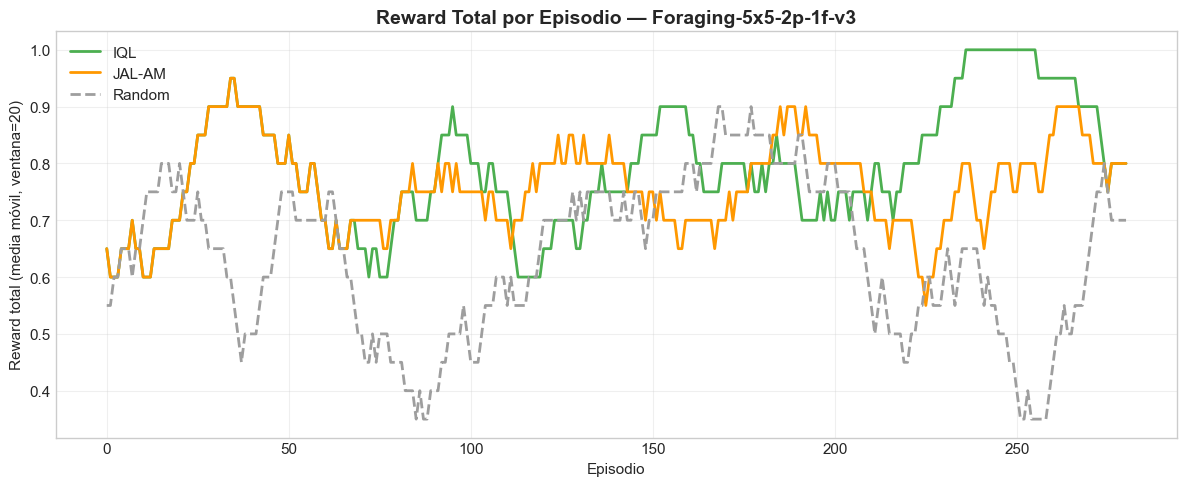

Reward promedio (últimos 50 episodios):
  IQL:    0.900
  JAL-AM: 0.800
  Random: 0.580


In [15]:
config = "Foraging-5x5-2p-1f-v3"
n_ep = 300

import warnings
warnings.filterwarnings('ignore')

iql_rewards = run_foraging_experiment(config, 'IQL', n_episodes=n_ep)
jal_rewards = run_foraging_experiment(config, 'JAL', n_episodes=n_ep)
rnd_rewards = run_foraging_experiment(config, 'Random', n_episodes=n_ep)

def smooth(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(smooth(iql_rewards), label='IQL', color=AGENT_COLORS['IQL'], linewidth=2)
ax.plot(smooth(jal_rewards), label='JAL-AM', color=AGENT_COLORS['JAL'], linewidth=2)
ax.plot(smooth(rnd_rewards), label='Random', color=AGENT_COLORS['Random'], linewidth=2, linestyle='--')

ax.set_title(f'Reward Total por Episodio — {config}', fontsize=14, fontweight='bold')
ax.set_xlabel('Episodio')
ax.set_ylabel('Reward total (media móvil, ventana=20)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Reward promedio (últimos 50 episodios):")
print(f"  IQL:    {np.mean(iql_rewards[-50:]):.3f}")
print(f"  JAL-AM: {np.mean(jal_rewards[-50:]):.3f}")
print(f"  Random: {np.mean(rnd_rewards[-50:]):.3f}")

### Análisis de Convergencia en Foraging
Foraging es el único ambiente con múltiples estados y episodios secuenciales, donde los agentes deben navegar una grilla 5x5 para recoger comida. A diferencia de los juegos matriciales, acá las acciones pasadas afectan el estado futuro, lo que hace que Q-learning tenga sentido.

Los resultados muestran que IQL y JAL aprenden a recoger la comida significativamente mejor que Random — 0.900 y 0.800 vs 0.580 en los últimos 50 episodios. Sin embargo, los tres muestran bastante varianza a lo largo del entrenamiento, lo que refleja la naturaleza estocástica del ambiente.

IQL supera a JAL en este ambiente. Esto probablemente se debe a que JAL mantiene una tabla Q sobre acciones conjuntas, lo que hace que su espacio de aprendizaje sea más grande y necesite más episodios para converger. Con solo 300 episodios, IQL aprende más rápido al ser más simple.

---
## 8. Tabla Comparativa Consolidada

Resumen de los resultados de todos los torneos round-robin, mostrando el reward promedio de cada algoritmo en cada juego.

In [29]:
import pandas as pd

games = ['RPS', 'MP', 'Blotto', 'BoS', 'Chicken']
matrices = [rps_m, mp_m, blotto_m, bos_m, ch_m]

consolidated = {}
for agent_idx, agent in enumerate(AGENTS):
    consolidated[agent] = {}
    for game_name, matrix in zip(games, matrices):
        row = matrix[agent_idx]
        avg_reward = np.mean(row)
        consolidated[agent][game_name] = round(avg_reward, 3)

df = pd.DataFrame(consolidated).T
df.index.name = 'Agente'

print("=" * 60)
print("  TABLA COMPARATIVA — Reward Promedio por Juego")
print("=" * 60)
print(df.to_string())
print("=" * 60)

  TABLA COMPARATIVA — Reward Promedio por Juego
          RPS     MP  Blotto    BoS  Chicken
Agente                                      
FP     -0.186 -0.124   0.076  1.749    2.914
RM     -0.009  0.001   0.093  1.551    3.594
IQL     0.168  0.065  -0.003  0.941    5.465
JAL     0.011  0.073  -0.003  0.937    4.986
Random  0.008  0.003  -0.105  0.623    5.418


---
## 9. Conclusiones

Tras correr los experimentos, logramos comprobar algunas de las cosas vistas en clase. 

***FP y RM*** son los algoritmos más sólidos en juegos matriciales. Convergen al equilibrio de Nash en juegos de suma cero (RPS, MP, Blotto) y coordinan rápidamente en juegos de coordinación pura (BoS). Si bien tienen mecanismos distintos, obtienen resultados muy similares. Su debilidad aparece en Chicken, donde ser predecibles los convierte en víctimas de agentes que colapsan a una estrategia fija.

***IQL y JAL*** no son los algoritmos indicados para juegos matriciales de una sola jugada. Su naturaleza de Q-learning asume un entorno estacionario que en sistemas multiagente no se cumple. En cambio, en Foraging demuestran su valor real: aprenden a recoger comida significativamente mejor que Random en pocos episodios. IQL resulta más eficiente que JAL en este ambiente porque su espacio de aprendizaje es más pequeño.

Para nostros, el resultado más inesperado del obligatorio fue Chicken: IQL y JAL dominaron el torneo no por aprender mejor, sino por colapsar a una estrategia determinista que FP y RM no supieron contrarrestar.